# UNAM - Facultad de Ciencias
## Inteligencia Artificial - Tema 4: Algoritmos de Aprendizaje
### Examen Final - Ejercicios Completos (Parte I + Parte II)

**Dra. Jessica Sarahi Méndez Rincón**

Este notebook contiene la solución completa a los 20 ejercicios (10 supervisados + 10 no supervisados) de las Actividades 1 y 5.  
Cada ejercicio incluye: el planteamiento, la solución matemática paso a paso, el código en Python, métricas y la interpretación.

---

## ⚙️ Setup - Imports comunes

Ejecuta esta celda **antes que todo lo demás**. Importa las librerías que se usan en todo el notebook.

In [1]:
# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Métricas y modelos de scikit-learn
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, mean_absolute_error,
                              mean_squared_error, classification_report)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder

np.random.seed(42)
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
# 🟦 PARTE I — Aprendizaje Supervisado y Métricas
---

## Ejercicio 1: Matriz de Confusión + Métricas básicas

**Datos:** TP = 50, FP = 10, FN = 5, TN = 35

### Solución matemática paso a paso

**Matriz de confusión:**

|              | Pred. Positivo | Pred. Negativo |
|--------------|:--------------:|:--------------:|
| Real Positivo |    TP = 50     |     FN = 5     |
| Real Negativo |    FP = 10     |    TN = 35     |

**Fórmulas y cálculos:**

- **Accuracy** = (TP + TN) / (TP + TN + FP + FN) = (50 + 35) / 100 = **0.85**
- **Precision** = TP / (TP + FP) = 50 / 60 = **0.833**
- **Recall** = TP / (TP + FN) = 50 / 55 = **0.909**
- **F1-score** = 2 · (P · R) / (P + R) = 2 · (0.833 · 0.909) / (0.833 + 0.909) = **0.870**

### Discusión: ¿Qué métrica priorizar en detección de enfermedad?
**RECALL (Sensibilidad).** En contextos médicos, un Falso Negativo (decir 'no estás enfermo' cuando sí lo estás) puede costar vidas. Recall mide qué tan bien detectamos todos los positivos reales.

In [2]:
# Ejercicio 1 - Verificación con código
TP, FP, FN, TN = 50, 10, 5, 35

matriz = np.array([[TP, FN],
                   [FP, TN]])
print('Matriz de confusión:')
print(pd.DataFrame(matriz,
                   index=['Real Positivo', 'Real Negativo'],
                   columns=['Pred. Positivo', 'Pred. Negativo']))

accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(f'\nAccuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

print('\n🩺 En detección de enfermedad priorizamos RECALL: minimizar Falsos Negativos.')

Matriz de confusión:
               Pred. Positivo  Pred. Negativo
Real Positivo              50               5
Real Negativo              10              35

Accuracy : 0.8500
Precision: 0.8333
Recall   : 0.9091
F1-score : 0.8696

🩺 En detección de enfermedad priorizamos RECALL: minimizar Falsos Negativos.


---
## Ejercicio 2: Métricas con desbalance de clases (dataset médico)

Dataset: solo 5% positivos.

|               | Pred: Sí | Pred: No |
|---------------|:--------:|:--------:|
| **Real: Sí**  |    8     |    2     |
| **Real: No**  |   90     |  900     |

Aquí: TP=8, FN=2, FP=90, TN=900.

### Cálculos

- Accuracy = (8 + 900) / 1000 = **0.908**
- Precision = 8 / (8 + 90) = 8/98 = **0.0816**
- Recall = 8 / (8 + 2) = 8/10 = **0.80**

### Respuestas
1. **¿Accuracy es buena métrica aquí?** NO. Con 99% negativos, un modelo que dijera 'todo es No' tendría ~99% accuracy y sería inútil.
2. **Recall = 0.80 / Precision = 0.0816** (calculado arriba).
3. **¿Qué priorizar?** En medicina **Recall**, para no dejar pasar enfermos. Si los falsos positivos generan tratamientos costosos, también vigilar Precision (usar **F1-score**).
4. **¿Buen modelo?** Detecta 80% de los enfermos (bueno) pero genera 90 falsas alarmas por cada 8 aciertos (malo en precision). Útil como filtro inicial, pero requiere prueba confirmatoria.

In [3]:
# Ejercicio 2
TP, FN, FP, TN = 8, 2, 90, 900
total = TP + FN + FP + TN

accuracy  = (TP + TN) / total
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(f'Total muestras: {total}')
print(f'Accuracy : {accuracy:.4f}  ⚠️ Engañosa por desbalance')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

# Modelo trivial 'todo es No' para comparar:
acc_trivial = (FP + TN) / total
print(f'\nAccuracy del modelo trivial "todo es No": {acc_trivial:.4f}')
print('→ El modelo trivial supera al modelo en accuracy. Por eso accuracy NO sirve aquí.')

Total muestras: 1000
Accuracy : 0.9080  ⚠️ Engañosa por desbalance
Precision: 0.0816
Recall   : 0.8000
F1-score : 0.1481

Accuracy del modelo trivial "todo es No": 0.9900
→ El modelo trivial supera al modelo en accuracy. Por eso accuracy NO sirve aquí.


---
## Ejercicio 3: Error en regresión (MAE vs MSE)

| Real | Pred |
|------|------|
| 100  |  90  |
| 200  | 210  |
| 300  | 1000 |

### Cálculos

Errores: |100-90|=10, |200-210|=10, |300-1000|=700

- **MAE** = (10 + 10 + 700) / 3 = 720/3 = **240**
- **MSE** = (10² + 10² + 700²) / 3 = (100 + 100 + 490000) / 3 = 490200 / 3 = **163,400**

### Reflexión
**MSE** penaliza más los errores grandes porque los **eleva al cuadrado**. El error de 700 contribuye con 490,000 al MSE pero solo con 700 al MAE. Por eso MSE es muy sensible a outliers.

In [4]:
# Ejercicio 3
y_real = np.array([100, 200, 300])
y_pred = np.array([90, 210, 1000])

errores = y_real - y_pred
print(f'Errores: {errores}')

mae = np.mean(np.abs(errores))
mse = np.mean(errores**2)
rmse = np.sqrt(mse)

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')

# Verificación con sklearn
print(f'\nVerificación sklearn:')
print(f'MAE: {mean_absolute_error(y_real, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_real, y_pred):.2f}')

print('\n📌 MSE penaliza más los errores grandes (los eleva al cuadrado).')

Errores: [  10  -10 -700]
MAE  : 240.00
MSE  : 163400.00
RMSE : 404.23

Verificación sklearn:
MAE: 240.00
MSE: 163400.00

📌 MSE penaliza más los errores grandes (los eleva al cuadrado).


---
## Ejercicio 4: Regresión Lineal — Interpretación de coeficientes

Modelo: **y = 5 + 2·x₁ − 3·x₂**

### Interpretación

- **Intercepto = 5**: cuando x₁ = 0 y x₂ = 0, y vale 5.
- **β₁ = 2** (coef. de x₁): si x₁ aumenta 1 unidad (manteniendo x₂ fija), **y aumenta 2 unidades**.
- **β₂ = −3** (coef. de x₂): si x₂ aumenta 1 unidad (manteniendo x₁ fija), **y disminuye 3 unidades**.

### ¿Qué pasa si x₂ aumenta?
y disminuye 3 unidades por cada unidad que aumente x₂. La relación entre x₂ e y es **negativa**.

In [5]:
# Ejercicio 4 - Demostración
def y(x1, x2):
    return 5 + 2*x1 - 3*x2

print(f'y(0, 0) = {y(0, 0)}    ← intercepto')
print(f'y(1, 0) = {y(1, 0)}    ← x1 sube 1 → y sube 2')
print(f'y(0, 1) = {y(0, 1)}    ← x2 sube 1 → y baja 3')
print(f'y(2, 1) = {y(2, 1)}')
print(f'y(2, 5) = {y(2, 5)}    ← x2 grande → y muy negativa')

y(0, 0) = 5    ← intercepto
y(1, 0) = 7    ← x1 sube 1 → y sube 2
y(0, 1) = 2    ← x2 sube 1 → y baja 3
y(2, 1) = 6
y(2, 5) = -6    ← x2 grande → y muy negativa


---
## Ejercicio 5: Regresión Logística — Interpretación

Modelo: **P(y=1 | x) = 1 / (1 + e^{-(2x − 4)})**

### Respuestas

**¿Qué pasa cuando x = 2?**
- Exponente: 2(2) − 4 = 0
- P(y=1 | x=2) = 1 / (1 + e⁰) = 1/(1+1) = **0.5**
- En x = 2 la probabilidad es exactamente 0.5 → el modelo está **indeciso**.

**¿Cuál es el umbral de decisión?**
- El umbral por defecto es 0.5. Se cumple cuando 2x − 4 = 0 → **x = 2**.
- Para x > 2 → P > 0.5 → clase 1.
- Para x < 2 → P < 0.5 → clase 0.

**¿Qué significa el coeficiente 2?**
- Es la **pendiente del logit**: indica qué tan rápido sube la probabilidad al aumentar x.
- Un coeficiente alto (positivo) → curva sigmoide más empinada → transición rápida entre clases.
- En odds: por cada unidad que aumenta x, el logaritmo de odds (log(p/(1-p))) aumenta 2 → los odds se multiplican por e² ≈ 7.39.

P(y=1 | x=2) = 0.5000  ← umbral, indeciso
P(y=1 | x=0) = 0.0180  ← clase 0
P(y=1 | x=4) = 0.9820  ← clase 1


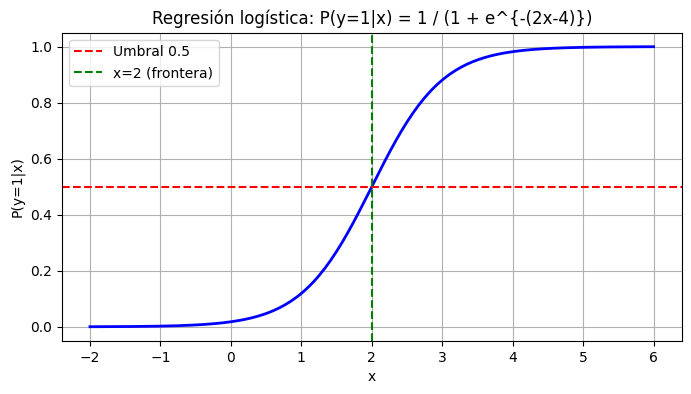

In [6]:
# Ejercicio 5
def sigmoide(x):
    return 1 / (1 + np.exp(-(2*x - 4)))

# Punto x = 2
print(f'P(y=1 | x=2) = {sigmoide(2):.4f}  ← umbral, indeciso')
print(f'P(y=1 | x=0) = {sigmoide(0):.4f}  ← clase 0')
print(f'P(y=1 | x=4) = {sigmoide(4):.4f}  ← clase 1')

# Visualización
x = np.linspace(-2, 6, 200)
plt.figure(figsize=(8, 4))
plt.plot(x, sigmoide(x), 'b-', linewidth=2)
plt.axhline(0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.axvline(2, color='green', linestyle='--', label='x=2 (frontera)')
plt.xlabel('x'); plt.ylabel('P(y=1|x)')
plt.title('Regresión logística: P(y=1|x) = 1 / (1 + e^{-(2x-4)})')
plt.legend(); plt.grid(True); plt.show()

---
## Ejercicio 6: SVM — Margen máximo

Puntos:
- Clase **+1**: (2,2), (3,3)
- Clase **−1**: (0,0), (1,1)

### Solución intuitiva

Todos los puntos están sobre la diagonal y = x. La recta separadora **óptima** es la que pasa entre (1,1) y (2,2) **perpendicular** a la diagonal:

**Recta separadora:** x + y = 3 (o equivalente, y = -x + 3)

**Vectores de soporte** (los más cercanos al margen): **(1,1)** y **(2,2)**.

El margen es la distancia perpendicular entre el hiperplano y los vectores de soporte.

Vectores de soporte: 
[[1. 1.]
 [2. 2.]]
Coeficientes (w): [1. 1.]
Bias (b): -3.0000


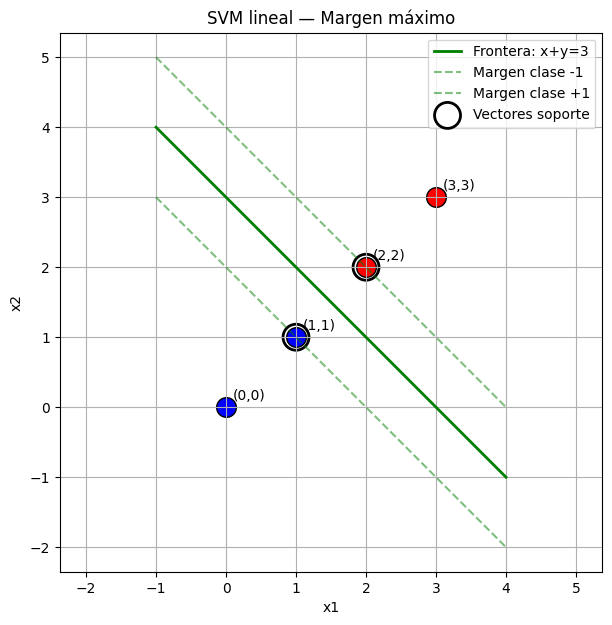

In [7]:
# Ejercicio 6
X = np.array([[2,2],[3,3],[0,0],[1,1]])
y_lab = np.array([1, 1, -1, -1])

# Entrenar SVM lineal
svm = SVC(kernel='linear', C=1e6)
svm.fit(X, y_lab)
print(f'Vectores de soporte: \n{svm.support_vectors_}')
print(f'Coeficientes (w): {svm.coef_[0]}')
print(f'Bias (b): {svm.intercept_[0]:.4f}')

# Visualización
plt.figure(figsize=(7, 7))
for i, p in enumerate(X):
    color = 'red' if y_lab[i]==1 else 'blue'
    plt.scatter(p[0], p[1], c=color, s=200, edgecolors='black')
    plt.annotate(f'({p[0]},{p[1]})', (p[0]+0.1, p[1]+0.1))

# Frontera y márgenes
xx = np.linspace(-1, 4, 50)
yy = -xx + 3  # x+y=3
plt.plot(xx, yy, 'g-', linewidth=2, label='Frontera: x+y=3')
plt.plot(xx, -xx + 2, 'g--', alpha=0.5, label='Margen clase -1')
plt.plot(xx, -xx + 4, 'g--', alpha=0.5, label='Margen clase +1')
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            s=350, facecolors='none', edgecolors='black', linewidths=2,
            label='Vectores soporte')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('SVM lineal — Margen máximo')
plt.legend(); plt.grid(True); plt.axis('equal')
plt.show()

---
## Ejercicio 7: SVM con Kernel — Conceptos

### Respuestas conceptuales

1. **¿Por qué falla un SVM lineal?**  
   Porque busca un hiperplano (recta en 2D, plano en 3D) y si los datos no son separables linealmente —por ejemplo dos clases en forma de círculos concéntricos— ninguna recta puede separarlos correctamente.

2. **¿Por qué usar un kernel?**  
   Un kernel **transforma los datos a un espacio de mayor dimensión** donde sí pueden ser linealmente separables, sin tener que calcular explícitamente esa transformación (truco del kernel: solo se necesita el producto punto en el nuevo espacio).

3. **Kernel RBF en datos circulares:**  
   El kernel RBF (Radial Basis Function / Gaussiano) mide similitud por **distancia entre puntos**. Mapea los datos a un espacio infinito-dimensional donde la 'distancia al centro' se vuelve una nueva dimensión. Los puntos del círculo interior quedan agrupados, los del exterior también, y un hiperplano en ese espacio los separa fácilmente.

4. **Ejemplo real:**  
   - Reconocimiento de rostros (relaciones no lineales entre píxeles).
   - Diagnóstico médico (relaciones complejas entre múltiples biomarcadores).
   - Detección de fraude bancario.

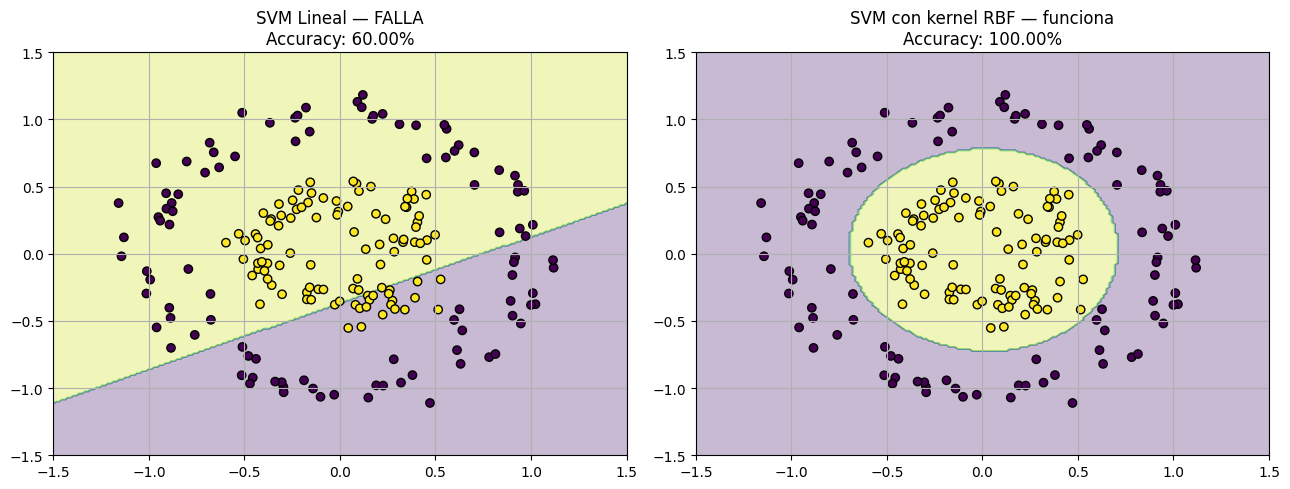

In [8]:
# Ejercicio 7 - Demostración: datos en círculo
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for idx, (kernel, title) in enumerate([('linear', 'SVM Lineal — FALLA'),
                                       ('rbf',    'SVM con kernel RBF — funciona')]):
    clf = SVC(kernel=kernel, gamma='auto')
    clf.fit(X, y)
    score = clf.score(X, y)
    
    xx, yy = np.meshgrid(np.linspace(-1.5,1.5,200), np.linspace(-1.5,1.5,200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3)
    axes[idx].scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    axes[idx].set_title(f'{title}\nAccuracy: {score:.2%}')
    axes[idx].grid(True)

plt.tight_layout(); plt.show()

---
## Ejercicio 8: K-NN — Clasificación manual

Puntos:
- **Clase A**: (1,1), (2,2)
- **Clase B**: (4,4), (5,5)
- **Nuevo punto**: (3,3)

### Distancias euclidianas desde (3,3)

- d a (1,1) = √(4+4) = √8 ≈ **2.83** [A]
- d a (2,2) = √(1+1) = √2 ≈ **1.41** [A]
- d a (4,4) = √(1+1) = √2 ≈ **1.41** [B]
- d a (5,5) = √(4+4) = √8 ≈ **2.83** [B]

### Resultados

1. **k = 1**: empate entre (2,2)[A] y (4,4)[B] (ambas a √2). Por convención sklearn elige el primero que encuentra → suele resolverse por orden o por azar.
2. **k = 3**: los 3 más cercanos son (2,2)[A], (4,4)[B], y empate entre (1,1) y (5,5). Si se incluye uno: **2 vs 1** según cuál → empate frecuente.
3. **¿Qué cambia?** El valor de **k** afecta la decisión. Aquí (3,3) está justo en la frontera por simetría → caso límite ideal para mostrar que **la elección de k es crítica**.

In [9]:
# Ejercicio 8
X = np.array([[1,1],[2,2],[4,4],[5,5]])
y_lab = np.array(['A','A','B','B'])
nuevo = np.array([[3,3]])

# Distancias manuales
for p, lab in zip(X, y_lab):
    d = np.linalg.norm(p - nuevo[0])
    print(f'd((3,3) → {tuple(p)}) = {d:.4f}  Clase: {lab}')

# Clasificación con sklearn
for k in [1, 3]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y_lab)
    pred = knn.predict(nuevo)
    print(f'\nClasificación con k={k}: {pred[0]}')

print('\n📌 (3,3) está exactamente en la frontera; el resultado depende de cómo sklearn rompe empates.')

d((3,3) → (np.int64(1), np.int64(1))) = 2.8284  Clase: A
d((3,3) → (np.int64(2), np.int64(2))) = 1.4142  Clase: A
d((3,3) → (np.int64(4), np.int64(4))) = 1.4142  Clase: B
d((3,3) → (np.int64(5), np.int64(5))) = 2.8284  Clase: B

Clasificación con k=1: A

Clasificación con k=3: A

📌 (3,3) está exactamente en la frontera; el resultado depende de cómo sklearn rompe empates.


---
## Ejercicio 9: K-NN — Escalamiento de variables

Dataset con:
- **Edad**: rango 0–100
- **Ingreso**: rango 0–1,000,000

### Problema
K-NN se basa en **distancias**. Si una variable tiene un rango 10,000 veces mayor (Ingreso), domina por completo el cálculo de distancia y la Edad se vuelve irrelevante. Dos personas con misma edad pero ingresos diferentes parecerán 'lejanas' aunque solo difieran en una característica.

### Solución
**Normalizar o estandarizar** ambas variables al mismo rango.

- **Normalización Min-Max**: x' = (x - min) / (max - min) → rango [0, 1].
- **Estandarización Z-score**: x' = (x - μ) / σ → media 0, desviación 1.

In [10]:
# Ejercicio 9 - Demostración del problema
datos = pd.DataFrame({
    'Edad':    [25, 30, 26, 60],
    'Ingreso': [50000, 1000000, 51000, 49500]
})
print('Datos originales:')
print(datos)

# Distancia entre punto 0 y los demás SIN escalar
print('\n❌ Distancias SIN escalar:')
for i in range(1, 4):
    d = np.linalg.norm(datos.iloc[0] - datos.iloc[i])
    print(f'  P0 → P{i}: {d:.2f}')

# Estandarizar
scaler = StandardScaler()
datos_escalados = pd.DataFrame(scaler.fit_transform(datos), columns=datos.columns)
print('\nDatos estandarizados (Z-score):')
print(datos_escalados.round(3))

print('\n✅ Distancias TRAS escalar:')
for i in range(1, 4):
    d = np.linalg.norm(datos_escalados.iloc[0] - datos_escalados.iloc[i])
    print(f'  P0 → P{i}: {d:.2f}')

print('\n📌 Sin escalar, el ingreso DOMINA totalmente la distancia y enmascara la edad.')

Datos originales:
   Edad  Ingreso
0    25    50000
1    30  1000000
2    26    51000
3    60    49500

❌ Distancias SIN escalar:
  P0 → P1: 950000.00
  P0 → P2: 1000.00
  P0 → P3: 501.22

Datos estandarizados (Z-score):
    Edad  Ingreso
0 -0.711   -0.578
1 -0.364    1.732
2 -0.642   -0.575
3  1.717   -0.579

✅ Distancias TRAS escalar:
  P0 → P1: 2.34
  P0 → P2: 0.07
  P0 → P3: 2.43

📌 Sin escalar, el ingreso DOMINA totalmente la distancia y enmascara la edad.


---
## Ejercicio 10: Naive Bayes — Clasificación probabilística

Probabilidades:

| Clase   | P(A) | P(B) |
|---------|------|------|
| Spam    | 0.6  | 0.7  |
| No Spam | 0.2  | 0.3  |

Priors: P(Spam) = 0.4 ; P(No Spam) = 0.6

Nuevo correo: contiene **A y B**.

### Cálculo de probabilidades (asumiendo independencia)

**Numerador para Spam:**  
P(A|Spam) · P(B|Spam) · P(Spam) = 0.6 · 0.7 · 0.4 = **0.168**

**Numerador para No Spam:**  
P(A|NoSpam) · P(B|NoSpam) · P(NoSpam) = 0.2 · 0.3 · 0.6 = **0.036**

**Normalizando** (P(datos) = 0.168 + 0.036 = 0.204):

- P(Spam | datos) = 0.168 / 0.204 = **0.8235**
- P(No Spam | datos) = 0.036 / 0.204 = **0.1765**

### Clasificación: **SPAM** (mayor probabilidad)

### ¿La independencia es real?
**No**, casi nunca lo es. Las palabras de un correo están correlacionadas (si aparece 'oferta', es más probable que aparezca 'gratis'). Por eso se llama **Naive** ('ingenuo'). A pesar de esa simplificación, en la práctica funciona sorprendentemente bien.

In [11]:
# Ejercicio 10
P_A_Spam, P_B_Spam       = 0.6, 0.7
P_A_NoSpam, P_B_NoSpam   = 0.2, 0.3
P_Spam, P_NoSpam         = 0.4, 0.6

num_spam   = P_A_Spam   * P_B_Spam   * P_Spam
num_nospam = P_A_NoSpam * P_B_NoSpam * P_NoSpam
evidencia  = num_spam + num_nospam

P_Spam_dado    = num_spam   / evidencia
P_NoSpam_dado  = num_nospam / evidencia

print(f'Numerador Spam   : {num_spam:.4f}')
print(f'Numerador NoSpam : {num_nospam:.4f}')
print(f'Evidencia P(datos): {evidencia:.4f}')
print(f'\nP(Spam   | datos) = {P_Spam_dado:.4f}  ({P_Spam_dado*100:.2f}%)')
print(f'P(NoSpam | datos) = {P_NoSpam_dado:.4f}  ({P_NoSpam_dado*100:.2f}%)')

clase = 'SPAM' if P_Spam_dado > P_NoSpam_dado else 'NO SPAM'
print(f'\n🎯 CLASIFICACIÓN: {clase}')
print('\nLa independencia de A y B casi nunca es real → "Naive".')

Numerador Spam   : 0.1680
Numerador NoSpam : 0.0360
Evidencia P(datos): 0.2040

P(Spam   | datos) = 0.8235  (82.35%)
P(NoSpam | datos) = 0.1765  (17.65%)

🎯 CLASIFICACIÓN: SPAM

La independencia de A y B casi nunca es real → "Naive".


---
# 🟩 PARTE II — Aprendizaje Supervisado avanzado y No Supervisado
---

## Ejercicio 1 (P2): Cálculo de Entropía

Dataset: Sí = 6, No = 4 → total = 10.

### Fórmula
$$H(S) = -\sum_{i} p_i \log_2(p_i)$$

- p(Sí) = 6/10 = 0.6
- p(No) = 4/10 = 0.4

$$H(S) = -(0.6 \cdot \log_2 0.6 + 0.4 \cdot \log_2 0.4)$$
$$H(S) = -(0.6 \cdot (-0.737) + 0.4 \cdot (-1.322))$$
$$H(S) = -(-0.442 - 0.529) = \mathbf{0.971}$$

**Interpretación**: 0.971 está cerca de 1 (máxima entropía para 2 clases) → el nodo está **bastante mezclado** = alta incertidumbre.

In [12]:
# Ejercicio 1 P2 - Función reutilizable de entropía
def entropia(conteos):
    """Calcula la entropía de Shannon dado una lista/array de conteos por clase."""
    conteos = np.array(conteos, dtype=float)
    total = conteos.sum()
    if total == 0:
        return 0.0
    p = conteos / total
    p = p[p > 0]  # evitar log(0)
    return -np.sum(p * np.log2(p))

H = entropia([6, 4])
print(f'Entropía del nodo (6 Sí, 4 No) = {H:.4f}')
print('→ Cerca de 1 → nodo muy mezclado = alta incertidumbre')

Entropía del nodo (6 Sí, 4 No) = 0.9710
→ Cerca de 1 → nodo muy mezclado = alta incertidumbre


---
## Ejercicio 2 (P2): Ganancia de Información — Construcción del árbol

Dataset:

| Clima    | Humedad | Viento | Jugar |
|----------|---------|--------|-------|
| Soleado  | Alta    | No     | No    |
| Soleado  | Alta    | Sí     | No    |
| Nublado  | Alta    | No     | Sí    |
| Lluvioso | Media   | No     | Sí    |
| Lluvioso | Baja    | No     | Sí    |
| Lluvioso | Baja    | Sí     | No    |
| Nublado  | Baja    | Sí     | Sí    |
| Soleado  | Media   | No     | No    |

### Paso 1 — Entropía inicial
8 muestras: 4 Sí, 4 No → H(S) = -(0.5·log₂0.5 + 0.5·log₂0.5) = **1.0** (máxima)

### Paso 2 — Ganancia por atributo
**Ganancia(A) = H(S) - Σ (|Sᵥ|/|S|) · H(Sᵥ)**

El código de abajo lo calcula automáticamente y elige la raíz.

In [13]:
# Ejercicio 2 P2
df = pd.DataFrame({
    'Clima':   ['Soleado','Soleado','Nublado','Lluvioso','Lluvioso','Lluvioso','Nublado','Soleado'],
    'Humedad': ['Alta','Alta','Alta','Media','Baja','Baja','Baja','Media'],
    'Viento':  ['No','Si','No','No','No','Si','Si','No'],
    'Jugar':   ['No','No','Si','Si','Si','No','Si','No']
})
print(df, '\n')

def entropia_serie(serie):
    return entropia(serie.value_counts().values)

def ganancia(df, atributo, target='Jugar'):
    H_total = entropia_serie(df[target])
    n = len(df)
    H_cond = 0
    for valor, sub in df.groupby(atributo):
        H_cond += (len(sub)/n) * entropia_serie(sub[target])
    return H_total - H_cond

H_inicial = entropia_serie(df['Jugar'])
print(f'Entropía inicial: H(Jugar) = {H_inicial:.4f}\n')

for atr in ['Clima', 'Humedad', 'Viento']:
    g = ganancia(df, atr)
    print(f'  Ganancia({atr}) = {g:.4f}')

ganancias = {atr: ganancia(df, atr) for atr in ['Clima', 'Humedad', 'Viento']}
raiz = max(ganancias, key=ganancias.get)
print(f'\n🌳 Raíz del árbol: {raiz} (mayor ganancia = {ganancias[raiz]:.4f})')

      Clima Humedad Viento Jugar
0   Soleado    Alta     No    No
1   Soleado    Alta     Si    No
2   Nublado    Alta     No    Si
3  Lluvioso   Media     No    Si
4  Lluvioso    Baja     No    Si
5  Lluvioso    Baja     Si    No
6   Nublado    Baja     Si    Si
7   Soleado   Media     No    No 

Entropía inicial: H(Jugar) = 1.0000

  Ganancia(Clima) = 0.6556
  Ganancia(Humedad) = 0.0613
  Ganancia(Viento) = 0.0488

🌳 Raíz del árbol: Clima (mayor ganancia = 0.6556)


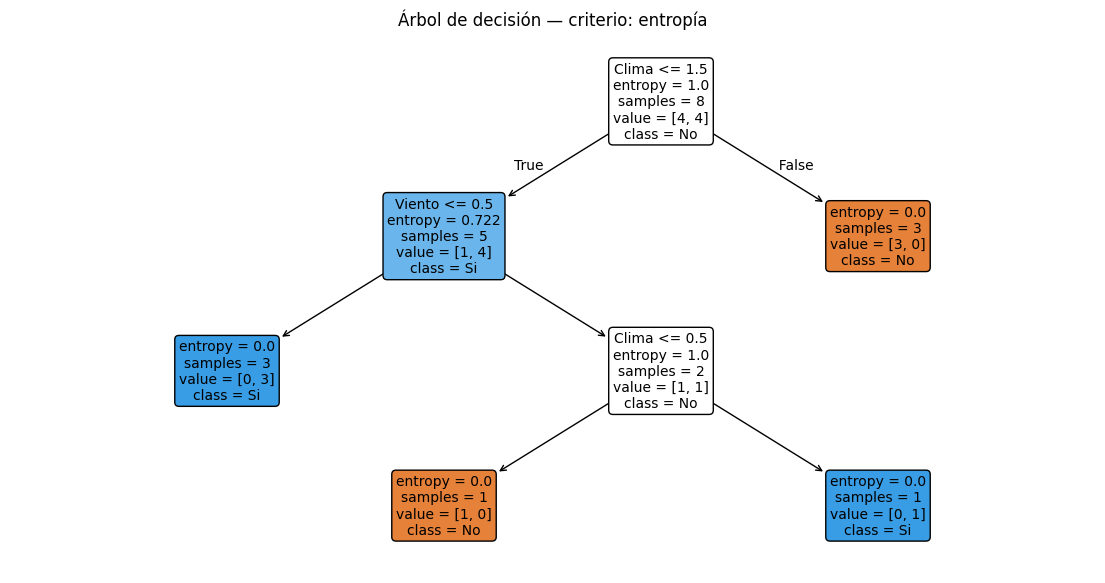

In [14]:
# Construcción visual del árbol con sklearn
df_enc = df.copy()
encoders = {col: LabelEncoder().fit(df_enc[col]) for col in df_enc.columns}
for col in df_enc.columns:
    df_enc[col] = encoders[col].transform(df_enc[col])

X = df_enc[['Clima','Humedad','Viento']]
y = df_enc['Jugar']

tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree.fit(X, y)

plt.figure(figsize=(14, 7))
plot_tree(tree, feature_names=['Clima','Humedad','Viento'],
          class_names=['No','Si'], filled=True, rounded=True, fontsize=10)
plt.title('Árbol de decisión — criterio: entropía')
plt.show()

---
## Ejercicio 3 (P2): Random Forest — Bagging conceptual

5 árboles predicen: **[1, 0, 1, 1, 0]**

### Predicción final (voto mayoritario)
- Votos por 1: tres → **mayoría** 
- Votos por 0: dos

**Predicción final = 1** ✅

### ¿Por qué reduce varianza?
Cada árbol entrena con un **subconjunto aleatorio** de datos (bootstrap) y de variables. Sus errores son **independientes**. Al promediar/votar, los errores se cancelan parcialmente y la predicción agregada es más estable que la de un árbol solo. Promediar modelos diversos baja la varianza sin aumentar el sesgo (idea central del bagging).

In [15]:
# Ejercicio 3 P2
from collections import Counter
predicciones = [1, 0, 1, 1, 0]
votos = Counter(predicciones)
ganador = votos.most_common(1)[0][0]
print(f'Votos: {dict(votos)}')
print(f'Predicción final (voto mayoritario): {ganador}')

Votos: {1: 3, 0: 2}
Predicción final (voto mayoritario): 1


---
## Ejercicio 4 (P2): Random Forest — Overfitting

Escenario: un árbol tiene **profundidad 20**.

### Respuestas

1. **¿Qué problema existe?**  
   **Overfitting (sobreajuste)**: con profundidad muy alta el árbol memoriza los datos de entrenamiento (incluyendo ruido). Generaliza mal a datos nuevos.

2. **¿Cómo lo soluciona Random Forest?**  
   - Entrena **muchos árboles** sobre subconjuntos aleatorios (bootstrap) de los datos.
   - En cada split usa un subconjunto aleatorio de **features** (feature bagging).
   - Promedia/vota → suaviza los errores individuales.  
   Aunque cada árbol sobreajuste, el ensemble **reduce la varianza**.

3. **¿Qué pasa si todos los árboles son iguales?**  
   El bosque pierde su ventaja: si todos cometen los mismos errores, votar por ellos no aporta nada. **La diversidad es esencial** (de ahí el muestreo aleatorio de datos y features).

---
## Ejercicio 5 (P2): Boosting paso a paso

Predicción inicial: ŷ = [10, 10, 10]  
Reales: y = [12, 8, 15]

### Paso 1 — Calcular residuos
Residuo = y - ŷ
- 12 - 10 = **+2**
- 8  - 10 = **-2**
- 15 - 10 = **+5**

**Residuos: [2, -2, 5]**

### Paso 2 — Entrenar el siguiente modelo
El segundo modelo no predice y, sino los **residuos**. Aprende a corregir los errores. Si predice exactamente los residuos, el ensemble queda perfecto.

### Paso 3 — Nueva predicción (con learning rate η)
ŷ_nueva = ŷ_inicial + η · ŷ_residuos

Con η = 0.1 y residuos predichos = [2, -2, 5]:
- ŷ_nueva = [10 + 0.1·2, 10 + 0.1·(-2), 10 + 0.1·5] = **[10.2, 9.8, 10.5]**

Cada nueva iteración acerca más la predicción a los valores reales.

In [16]:
# Ejercicio 5 P2
y_real    = np.array([12, 8, 15])
y_inicial = np.array([10, 10, 10])
residuos  = y_real - y_inicial
print(f'Residuos: {residuos}')

# Simular varias iteraciones de boosting con learning rate 0.1
lr = 0.1
y_pred = y_inicial.astype(float).copy()
for it in range(1, 11):
    res = y_real - y_pred
    y_pred = y_pred + lr * res
    print(f'Iter {it:2d}: pred = {np.round(y_pred,3)},  residuos = {np.round(res,3)}')

print(f'\nValores reales: {y_real}')
print('Las predicciones se acercan iterativamente a los reales.')

Residuos: [ 2 -2  5]
Iter  1: pred = [10.2  9.8 10.5],  residuos = [ 2. -2.  5.]
Iter  2: pred = [10.38  9.62 10.95],  residuos = [ 1.8 -1.8  4.5]
Iter  3: pred = [10.542  9.458 11.355],  residuos = [ 1.62 -1.62  4.05]
Iter  4: pred = [10.688  9.312 11.719],  residuos = [ 1.458 -1.458  3.645]
Iter  5: pred = [10.819  9.181 12.048],  residuos = [ 1.312 -1.312  3.281]
Iter  6: pred = [10.937  9.063 12.343],  residuos = [ 1.181 -1.181  2.952]
Iter  7: pred = [11.043  8.957 12.609],  residuos = [ 1.063 -1.063  2.657]
Iter  8: pred = [11.139  8.861 12.848],  residuos = [ 0.957 -0.957  2.391]
Iter  9: pred = [11.225  8.775 13.063],  residuos = [ 0.861 -0.861  2.152]
Iter 10: pred = [11.303  8.697 13.257],  residuos = [ 0.775 -0.775  1.937]

Valores reales: [12  8 15]
Las predicciones se acercan iterativamente a los reales.


---
## Ejercicio 6 (P2): Random Forest vs Gradient Boosting

| Aspecto         | Random Forest                                | Gradient Boosting                                  |
|-----------------|----------------------------------------------|----------------------------------------------------|
| Estrategia      | **Bagging** — árboles en paralelo             | **Boosting** — árboles secuenciales                |
| Datos por árbol | Subconjunto aleatorio (bootstrap)            | Todos los datos (corrigen residuos previos)        |
| Combinación     | Voto mayoritario / promedio                  | Suma ponderada con learning rate                   |
| Reduce          | Varianza                                     | Sesgo                                              |
| Sobreajuste     | Menor (la diversidad protege)                 | **Mayor** (puede memorizar el ruido)               |
| Velocidad       | Paralelizable                                | Secuencial → más lento                             |
| Interpretabilidad | Mejor (árboles independientes)             | Peor (modelo aditivo encadenado)                   |

### Respuestas
1. **Diferencia clave**: bagging paralelo vs boosting secuencial.
2. **Sobreajusta más fácilmente**: **Gradient Boosting** (sin regularización).
3. **Más interpretable**: **Random Forest** (cada árbol es independiente; se puede analizar feature importance fácilmente).

---
## Ejercicio 7 (P2): K-Means — Iteración manual

Puntos: (1,1), (2,2), (8,8), (9,9)  
Centroides iniciales: C1 = (1,1), C2 = (9,9)

### Iteración 1

**Distancias al cuadrado a cada centroide:**

| Punto | d² a C1=(1,1) | d² a C2=(9,9) | Cluster |
|-------|---------------|---------------|---------|
| (1,1) | 0             | 128           | C1      |
| (2,2) | 2             | 98            | C1      |
| (8,8) | 98            | 2             | C2      |
| (9,9) | 128           | 0             | C2      |

**Recalcular centroides** (media de los puntos asignados):
- Nuevo C1 = ((1+2)/2, (1+2)/2) = **(1.5, 1.5)**
- Nuevo C2 = ((8+9)/2, (8+9)/2) = **(8.5, 8.5)**

### Iteración 2
Repitiendo el proceso, las asignaciones **no cambian** y los centroides quedan iguales → **convergencia**.

In [17]:
# Ejercicio 7 P2
puntos = np.array([[1,1],[2,2],[8,8],[9,9]])
centroides = np.array([[1,1],[9,9]], dtype=float)

for it in range(1, 4):
    # Asignar cada punto al centroide más cercano
    distancias = np.linalg.norm(puntos[:, None] - centroides[None, :], axis=2)
    asignacion = np.argmin(distancias, axis=1)
    print(f'Iteración {it} - asignación: {asignacion}')
    # Recalcular centroides
    nuevos = np.array([puntos[asignacion==k].mean(axis=0) for k in range(2)])
    print(f'  Centroides: C1={nuevos[0]}, C2={nuevos[1]}')
    if np.allclose(nuevos, centroides):
        print('  ✅ Convergencia alcanzada')
        break
    centroides = nuevos

# Verificación con sklearn
km = KMeans(n_clusters=2, init=np.array([[1,1],[9,9]], dtype=float), n_init=1, random_state=42)
km.fit(puntos)
print(f'\nsklearn — centroides finales: \n{km.cluster_centers_}')
print(f'Etiquetas: {km.labels_}')

Iteración 1 - asignación: [0 0 1 1]
  Centroides: C1=[1.5 1.5], C2=[8.5 8.5]
Iteración 2 - asignación: [0 0 1 1]
  Centroides: C1=[1.5 1.5], C2=[8.5 8.5]
  ✅ Convergencia alcanzada



sklearn — centroides finales: 
[[1.5 1.5]
 [8.5 8.5]]
Etiquetas: [0 0 1 1]


---
## Ejercicio 8 (P2): K-Means — Elección de K

### Respuestas

1. **K muy pequeño** → grupos muy grandes y heterogéneos. Pierde estructura fina (underfitting de clustering).
2. **K muy grande** → grupos muy pequeños, posiblemente uno por punto. Pierde generalización; es como memorizar los datos.
3. **Método del codo (elbow method):**
   - Entrenar K-Means para varios valores de K (1 a 10, por ejemplo).
   - Calcular la **inercia** (suma de distancias al cuadrado dentro de cada cluster, también llamada SSE).
   - Graficar inercia vs K. La curva siempre baja, pero hay un **codo** (cambio de pendiente).
   - El K óptimo es aproximadamente donde está ese codo: añadir más clusters ya no mejora mucho.

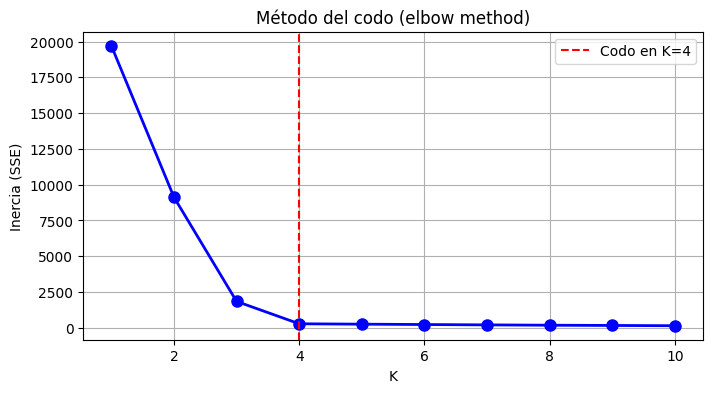

In [18]:
# Ejercicio 8 P2 - Demostración elbow
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)

inercias = []
Ks = range(1, 11)
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(Ks, inercias, 'bo-', linewidth=2, markersize=8)
plt.axvline(4, color='red', linestyle='--', label='Codo en K=4')
plt.xlabel('K'); plt.ylabel('Inercia (SSE)')
plt.title('Método del codo (elbow method)')
plt.legend(); plt.grid(True); plt.show()

---
## Ejercicio 9 (P2): DBSCAN — Clasificación de puntos

Parámetros: eps = 2, minPts = 3  
Puntos: (1,1), (2,1), (2,2), (8,8)

### Análisis manual de vecindarios

Distancias dentro del primer grupo:
- d((1,1),(2,1)) = 1 ≤ 2 ✓
- d((1,1),(2,2)) = √2 ≈ 1.41 ≤ 2 ✓
- d((2,1),(2,2)) = 1 ≤ 2 ✓

(8,8) está lejos: d((1,1),(8,8)) ≈ 9.9 > 2 ✗

**Vecindarios (incluyendo el propio punto):**
- Vecinos de (1,1): {(1,1), (2,1), (2,2)} → 3 ≥ minPts → **NÚCLEO** ✅
- Vecinos de (2,1): {(2,1), (1,1), (2,2)} → 3 ≥ minPts → **NÚCLEO** ✅
- Vecinos de (2,2): {(2,2), (1,1), (2,1)} → 3 ≥ minPts → **NÚCLEO** ✅
- Vecinos de (8,8): {(8,8)} → 1 < minPts → **RUIDO** ❌

### Resultado
- **Núcleos**: (1,1), (2,1), (2,2)
- **Borde**: ninguno (todos son núcleos)
- **Ruido**: (8,8)

In [19]:
# Ejercicio 9 P2
puntos = np.array([[1,1],[2,1],[2,2],[8,8]])
db = DBSCAN(eps=2, min_samples=3).fit(puntos)
etiquetas = db.labels_
indices_nucleo = db.core_sample_indices_

print('Etiquetas DBSCAN (-1 = ruido):', etiquetas)
print('Índices de puntos núcleo:', indices_nucleo)
for i, p in enumerate(puntos):
    if i in indices_nucleo:
        tipo = 'NÚCLEO'
    elif etiquetas[i] == -1:
        tipo = 'RUIDO'
    else:
        tipo = 'BORDE'
    print(f'  Punto {tuple(p)} → {tipo}, cluster: {etiquetas[i]}')

Etiquetas DBSCAN (-1 = ruido): [ 0  0  0 -1]
Índices de puntos núcleo: [0 1 2]
  Punto (np.int64(1), np.int64(1)) → NÚCLEO, cluster: 0
  Punto (np.int64(2), np.int64(1)) → NÚCLEO, cluster: 0
  Punto (np.int64(2), np.int64(2)) → NÚCLEO, cluster: 0
  Punto (np.int64(8), np.int64(8)) → RUIDO, cluster: -1


---
## Ejercicio 10 (P2): Isolation Forest — Detección de anomalías

Dataset: **[10, 12, 11, 13, 100]**

### Respuestas

1. **¿Cuál es la anomalía?**  
   **100**. Los demás valores se concentran en el rango [10, 13]; 100 está muy alejado.

2. **¿Por qué Isolation Forest lo detecta rápido?**  
   El algoritmo construye árboles haciendo **particiones aleatorias** del espacio. Un valor extremo se separa del resto en muy pocas particiones (a menudo 1 o 2 cortes lo aíslan). Los puntos normales requieren muchos más cortes porque están rodeados de vecinos similares.

3. **¿Qué significa 'profundidad corta'?**  
   La profundidad es el número de cortes (niveles del árbol) necesarios para aislar un punto. Si un punto se aísla con profundidad 1 o 2, es atípico. Las anomalías tienen **profundidad promedio corta** en muchos árboles aleatorios → score de anomalía alto.

In [20]:
# Ejercicio 10 P2
datos = np.array([10, 12, 11, 13, 100]).reshape(-1, 1)
iso = IsolationForest(contamination=0.2, random_state=42)
iso.fit(datos)
predicciones = iso.predict(datos)        # 1 = normal, -1 = anomalía
scores       = iso.decision_function(datos)  # más bajo = más anómalo

print('Punto | Score   | Predicción')
print('---------------------------')
for valor, p, s in zip(datos.flatten(), predicciones, scores):
    estado = 'ANOMALÍA ❗' if p == -1 else 'normal'
    print(f'{valor:5d} | {s:+.4f} | {estado}')

Punto | Score   | Predicción
---------------------------
   10 | +0.0610 | normal
   12 | +0.1338 | normal
   11 | +0.1348 | normal
   13 | +0.0597 | normal
  100 | -0.2387 | ANOMALÍA ❗


---
# 📌 Resumen Final

## Métricas (memorízalas)

**Clasificación (basadas en matriz de confusión):**
- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 = 2 · (P · R) / (P + R)

**Regresión:**
- MAE = (1/n) · Σ |yᵢ - ŷᵢ|
- MSE = (1/n) · Σ (yᵢ - ŷᵢ)²
- RMSE = √MSE

**Decisión de qué métrica priorizar:**
- Salud, fraude, seguridad → **Recall** (no quiero perder casos importantes).
- Spam, recomendación → **Precision** (no quiero molestar al usuario con falsos positivos).
- Datos balanceados → **Accuracy** está bien.
- Datos desbalanceados → **F1-score**.

## Algoritmos clave

| Algoritmo | Tipo | Uso |
|-----------|------|-----|
| Regresión lineal | Supervisado regresión | Predecir continuos |
| Regresión logística | Supervisado clasif. | Clasif. binaria |
| SVM | Supervisado clasif. | Maximiza margen |
| K-NN | Supervisado clasif./reg. | Vecinos cercanos |
| Naive Bayes | Supervisado clasif. | Probabilístico |
| Árbol decisión | Supervisado | Reglas if-else |
| Random Forest | Ensemble bagging | Reduce varianza |
| Gradient Boosting | Ensemble boosting | Reduce sesgo |
| K-Means | No sup. clustering | Particiones |
| DBSCAN | No sup. clustering | Por densidad |
| Isolation Forest | No sup. anomalías | Aislamiento |

**¡Mucha suerte en el examen! 🍀**